# 🌿 Plant Explorer
## Middle School Plant Science Investigation

In this notebook you will:
- 📋 Enter plant photos in a **data table**
- 🤖 Use **CLIP** (an AI vision model) to compare them — no API key needed
- 📊 Get **similarity scores** showing which known plant matches best
- 🔵 See plant embeddings **plotted in 2D space**
- 🗺️ **Map** where each plant was found

> **Only change lines marked ✏️**


---
## ⚙️ Setup — run this cell first


In [1]:
import subprocess, sys
for pkg in ["transformers", "torch", "Pillow", "folium", "scikit-learn", "datascience"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("✅ All packages ready!")



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


✅ All packages ready!



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from datascience import Table
from plant_identifier import (
    check_photos, load_clip,
    show_all_plants, extract_gps,
    compare_plants, plot_results, plot_embeddings, make_map
)
load_clip();
%matplotlib inline


Loading CLIP model (openai/clip-vit-base-patch32)…
First run: ~600 MB download — takes a minute. Cached after that.



Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

✅ CLIP model ready!



---
## 🧠 How does CLIP work?

CLIP converts every photo into **512 numbers** called an **embedding** —
like a GPS address in a 512-dimensional space. Photos that look similar
end up at nearby addresses. We measure closeness using **cosine similarity**,
the cosine of the angle between two vectors (1.0 = identical, 0.6 = very different).


---
## ✏️ Step 1 — Enter your plant photos in a table

Upload photos using the **file browser** on the left, then fill in the table.
Find GPS coordinates by right-clicking on [Google Maps](https://maps.google.com) → *What's here?*


In [3]:
# ✏️ Your mystery plant
mystery_photo = "mystery_plant.jpg"
mystery_lat   =  39.9526
mystery_lon   = -75.1652

# ✏️ Known plants — add or remove rows as needed
plants_table = Table().with_columns(
    "Name",       ["Dandelion",             "White Clover",       "Plantain"],
    "Photo",      ["plants/dandelion.jpg",  "plants/clover.jpg",  "plants/plantain.jpg"],
    "Latitude",   [39.9530,                 39.9528,              39.9522],
    "Longitude",  [-75.1648,               -75.1655,             -75.1660],
)
plants_table


Name,Photo,Latitude,Longitude
Dandelion,plants/dandelion.jpg,39.953,-75.1648
White Clover,plants/clover.jpg,39.9528,-75.1655
Plantain,plants/plantain.jpg,39.9522,-75.166


In [4]:
# Convert table rows to the format plant_identifier expects
known_plants = [
    {"name": row.item("Name"), "path": row.item("Photo")}
    for row in plants_table.rows
]
check_photos(mystery_photo, known_plants)


Checking photo files...

  ✅  Mystery Plant         →  mystery_plant.jpg  (21 KB)
  ✅  Dandelion             →  plants/dandelion.jpg  (27 KB)
  ✅  White Clover          →  plants/clover.jpg  (11 KB)
  ✅  Plantain              →  plants/plantain.jpg  (12 KB)

✅ All photos valid — ready to continue!


True

### 📷 Display all photos


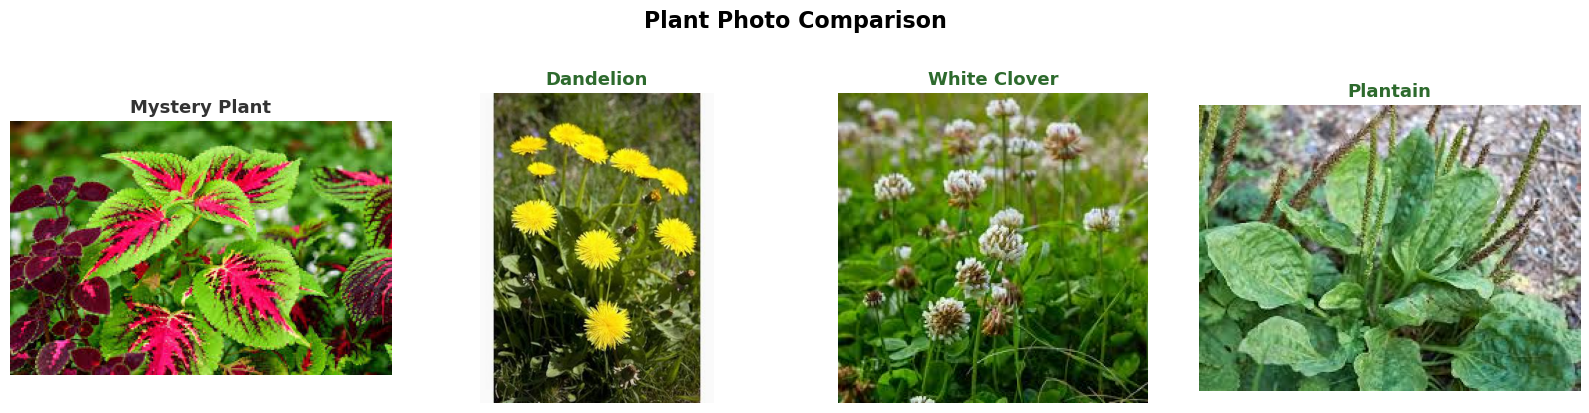

In [5]:
show_all_plants(mystery_photo, known_plants)


---
## 📍 Step 2 — GPS locations

Smartphones save GPS coordinates inside photo files as hidden *EXIF data*.
We read it automatically; if missing we use the table values.


In [6]:
all_entries = [
    {"name": "Mystery Plant",
     "lat_manual": mystery_lat, "lon_manual": mystery_lon,
     "path": mystery_photo}
] + [
    {"name": row.item("Name"),
     "lat_manual": row.item("Latitude"),
     "lon_manual": row.item("Longitude"),
     "path": row.item("Photo")}
    for row in plants_table.rows
]

plant_locations = []
print("Checking GPS data...\n")
for entry in all_entries:
    gps = extract_gps(entry["path"])
    if gps:
        source = "EXIF"
    else:
        gps    = {"latitude": entry["lat_manual"], "longitude": entry["lon_manual"]}
        source = "table"
    print(f"  ✅ {entry['name']:20s} → {gps['latitude']:.5f}, {gps['longitude']:.5f}  ({source})")
    plant_locations.append({"name": entry["name"], **gps})
print(f"\n📍 {len(plant_locations)} location(s) ready")


Checking GPS data...

  ✅ Mystery Plant        → 39.95260, -75.16520  (table)
  ✅ Dandelion            → 39.95300, -75.16480  (table)
  ✅ White Clover         → 39.95280, -75.16550  (table)
  ✅ Plantain             → 39.95220, -75.16600  (table)

📍 4 location(s) ready


---
## 🤖 Step 3 — Compare using CLIP

CLIP converts every photo to a 512-number vector and computes
cosine similarity. ⏳ Usually under 5 seconds.


In [7]:
result = compare_plants(mystery_photo, known_plants)


Computing CLIP embedding for mystery plant…
  Comparing with Dandelion…
  Comparing with White Clover…
  Comparing with Plantain…

✅ Done! Closest match: Plantain (54% similar)


### 📊 Similarity scores


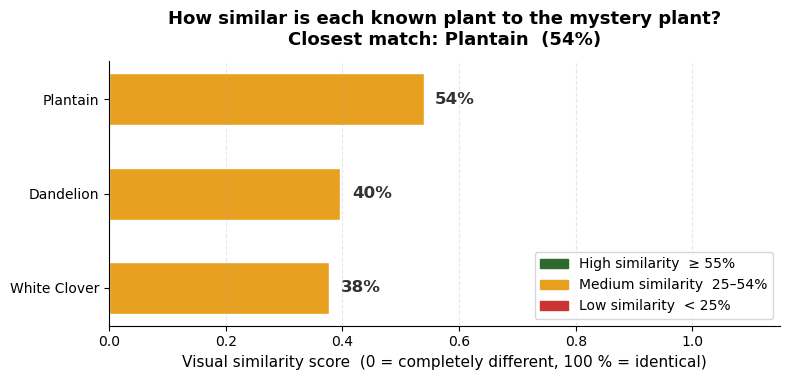


📋 Similarity scores (raw cosine values):
  Plantain                  [██████████░░░░░░░░░░] 54%  (cosine = 0.816)
  Dandelion                 [███████░░░░░░░░░░░░░] 40%  (cosine = 0.758)
  White Clover              [███████░░░░░░░░░░░░░] 38%  (cosine = 0.751)


In [8]:
plot_results(result)


---
## 🔵 Step 4 — Embedding space (PCA)

512 dimensions → 2D using PCA so we can plot them.
The mystery plant (red) should sit closest to its best match.


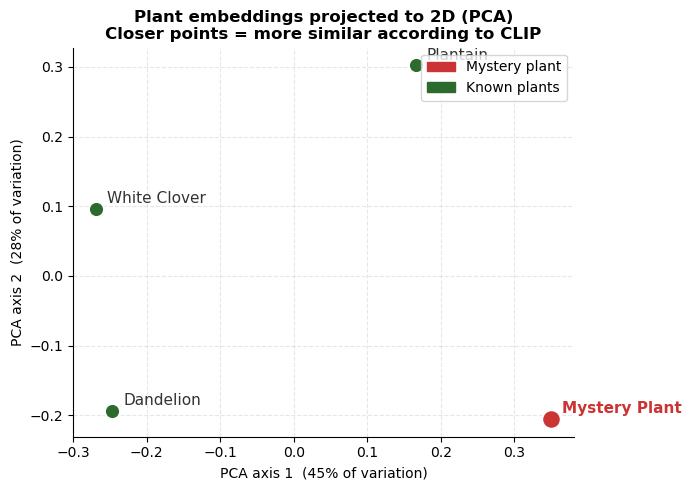

In [9]:
plot_embeddings(mystery_photo, known_plants)


---
## 🗺️ Step 5 — Map


In [10]:
make_map(plant_locations, zoom_start=15)


---
## 💬 Step 6 — Discuss

1. Which known plant had the highest score? Do you agree?
2. Look at the embedding plot — is the mystery plant near its best match?
3. What situations might fool CLIP? (lighting, angle, season)
4. **Extension 🌟** — add a photo of a rock or shoe. What score does it get?

---
## 🔭 Try this with other subjects!

The same notebook works for almost anything you can photograph:

| Subject | Science connection |
|---------|-------------------|
| 🦎 **Animals / insects** | Biodiversity surveys, species identification |
| 🪨 **Rocks & minerals** | Geology, crystal structure, colour analysis |
| 🍄 **Fungi** | Ecology, decomposition, mushroom safety |
| 🌥️ **Clouds** | Meteorology, atmospheric science |
| 🐚 **Shells / fossils** | Marine biology, palaeontology |
| 🌾 **Seeds & fruits** | Botany, agriculture, dispersal mechanisms |

To adapt: just swap the photos and update the `plants_table` rows!

*🌱 Great work, scientist! You used an AI vision model, cosine similarity,
PCA, GPS, and interactive maps — just like real researchers.*
